# Project: Hotel Booking Cancellation Prediction 
> Task: You are provided with a dataset of hotel bookings. The goal is to predict whether a booking will be canceled based on various features such as lead time, number of guests, meal preferences, and others. Your task is to build a classification model to predict the target variable is canceled, which indicates whether a booking was canceled (1) or not (0).

@Yevheniia-Rudenko 


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, classification_report, roc_curve, auc
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer




## Data overview

In [2]:
# Load labeled and unlabeled data
labeled_data = pd.read_csv("/Users/yevrud/redi_school_ML_AI/final_project/data/train.csv")
unlabeled_data = pd.read_csv("/Users/yevrud/redi_school_ML_AI/final_project/data/test.csv")

# Create copies of the datasets
df_train = labeled_data.copy()
df_test = unlabeled_data.copy()

# Save test IDs for final output
test_ids = df_test["id"].copy()


In [3]:
df_train.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card,id,estimated_check_in_duration,booking_difficulty_score
0,Resort Hotel,0,NaN,9,March,2017,2,0.820075,2.546977,1,...,0,Check-Out,2017-03-06,Edward Davis,EDavis@mail.com,129-327-5067,************1227,33852,NaN,NaN
1,City Hotel,0,82.916916,11,March,2017,15,-0.325630,2.002309,2,...,2,Check-Out,2017-03-16,Joshua Sullivan,JSullivan@zoho.com,748-584-5256,************7930,97750,47.282901,-3.218666
2,City Hotel,0,24.534646,44,October,2016,23,1.820523,1.289780,1,...,1,Check-Out,2016-10-25,Zachary Bishop,Bishop_Zachary@gmail.com,880-124-3628,************2924,100248,13.811002,3.859197
3,City Hotel,1,169.265992,12,March,2017,23,0.721699,1.848563,2,...,2,Canceled,2017-01-19,Victoria Kent,Victoria.Kent@aol.com,814-180-1532,************7923,65077,81.319112,1.510322
4,City Hotel,0,-22.240921,3,Veganuary,2017,19,-0.097702,1.045354,2,...,1,Canceled,2016-10-26,Michael Johnson,Johnson_Michael11@xfinity.com,118-263-8905,************9630,62714,-9.889995,4.345359


In [4]:
df_train.info()
df_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83573 entries, 0 to 83572
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83573 non-null  object 
 1   is_canceled                     83573 non-null  int64  
 2   lead_time                       79290 non-null  float64
 3   arrival_date_year               83573 non-null  int64  
 4   arrival_date_month              83573 non-null  object 
 5   arrival_date_week_number        83573 non-null  int64  
 6   arrival_date_day_of_month       83573 non-null  int64  
 7   stays_in_weekend_nights         83573 non-null  float64
 8   stays_in_week_nights            83573 non-null  float64
 9   adults                          83573 non-null  int64  
 10  children                        83571 non-null  float64
 11  babies                          83573 non-null  int64  
 12  meal                            

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,id,estimated_check_in_duration,booking_difficulty_score
count,83573.000000,79290.000000,83573.000000,83573.000000,83573.000000,83573.000000,83573.000000,83573.000000,83571.000000,83573.000000,...,83573.000000,72224.000000,4674.000000,83573.000000,79290.000000,83573.000000,83573.000000,83573.000000,79290.000000,79290.000000
mean,0.397210,103.379569,27.120326,2016.155912,15.788077,0.928752,2.492898,1.859225,0.102918,0.008137,...,0.220681,86.603774,186.998074,2.321765,101.735184,0.061790,0.572745,59698.368983,51.673768,1.293816
std,0.489323,119.376604,13.619669,0.707381,8.782488,1.118739,2.126703,0.594781,0.397277,0.096017,...,0.654785,110.672677,130.511313,19.326393,57.456359,0.243445,0.794273,34498.851794,60.534659,2.294587
min,0.000000,-227.156938,1.000000,2015.000000,1.000000,-1.791310,-3.794357,0.000000,0.000000,0.000000,...,0.000000,1.000000,9.000000,-36.442446,-80.136040,0.000000,0.000000,1.000000,-123.491940,-5.127325
25%,0.000000,18.369438,16.000000,2016.000000,8.000000,0.065392,1.105973,2.000000,0.000000,0.000000,...,0.000000,9.000000,59.000000,-5.701373,65.609982,0.000000,0.000000,29788.000000,8.512819,0.103028
50%,0.000000,79.567680,27.000000,2016.000000,16.000000,0.795712,2.217654,2.000000,0.000000,0.000000,...,0.000000,14.000000,174.000000,0.394790,96.152208,0.000000,0.000000,59782.000000,40.426761,1.090596
75%,1.000000,167.570697,38.000000,2017.000000,23.000000,1.713242,3.551786,2.000000,0.000000,0.000000,...,0.000000,229.000000,268.000000,6.589958,131.647735,0.000000,1.000000,89525.000000,84.541252,2.131485
max,1.000000,741.651834,53.000000,2017.000000,31.000000,19.232182,49.354003,55.000000,10.000000,9.000000,...,20.000000,535.000000,543.000000,401.792112,5411.546686,8.000000,5.000000,119390.000000,370.155876,55.593803


In [5]:
df_train.isnull().sum().sort_values(ascending=False)[lambda x : x > 0]

company                        78899
agent                          11349
country                         4540
meal                            4283
adr                             4283
booking_difficulty_score        4283
estimated_check_in_duration     4283
lead_time                       4283
children                           2
dtype: int64

In [6]:
cols = ["meal", "adr", "booking_difficulty_score", "estimated_check_in_duration", "lead_time"]
df_train[cols].isnull().all(axis=1).sum()


4283

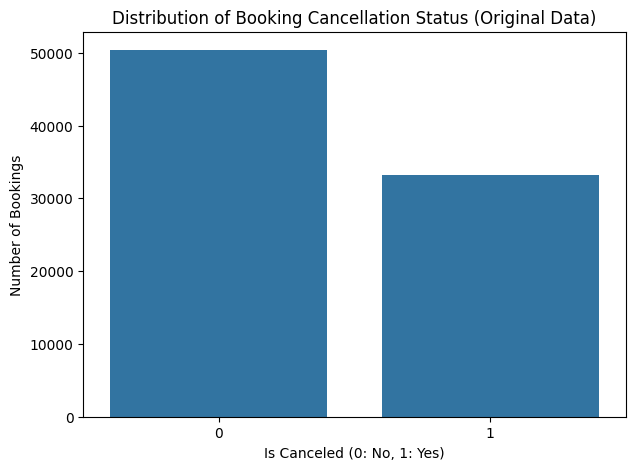

In [7]:
# Distribution of Target Variable 'is_canceled' (Before Cleaning/Outlier Removal) ---
plt.figure(figsize=(7, 5))
sns.countplot(x='is_canceled', data=df_train)
plt.title('Distribution of Booking Cancellation Status (Original Data)')
plt.xlabel('Is Canceled (0: No, 1: Yes)')
plt.ylabel('Number of Bookings')
plt.show()

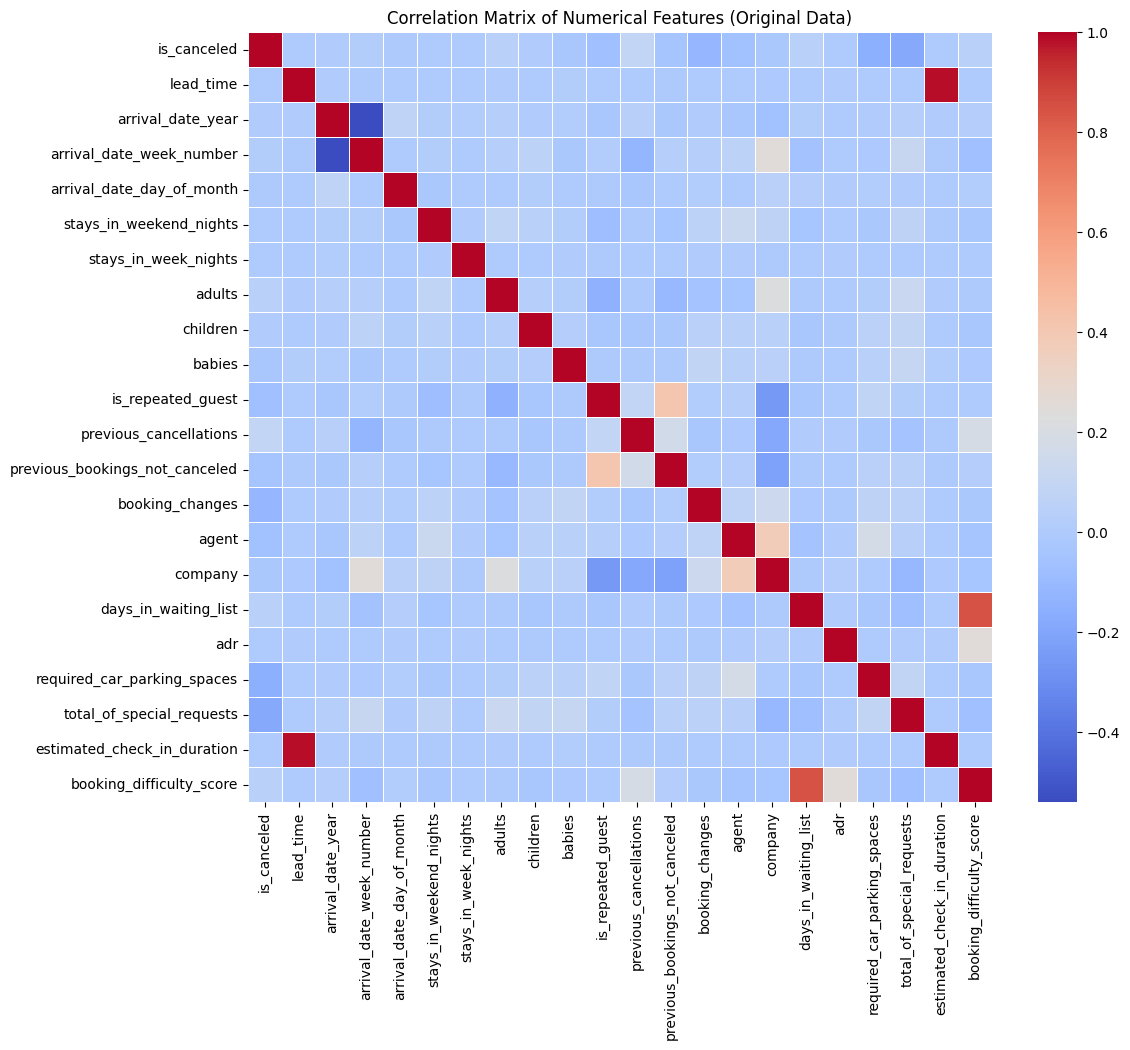

In [8]:
#Correlation Matrix of Numerical Features (Before Cleaning) ---
# Select only numerical columns for correlation
numerical_df_initial = df_train.select_dtypes(include=['float64', 'int64']).drop(columns=['id'], errors='ignore')
plt.figure(figsize=(12, 10))
sns.heatmap(numerical_df_initial.corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (Original Data)')
plt.show()

(22.0, 1.0)

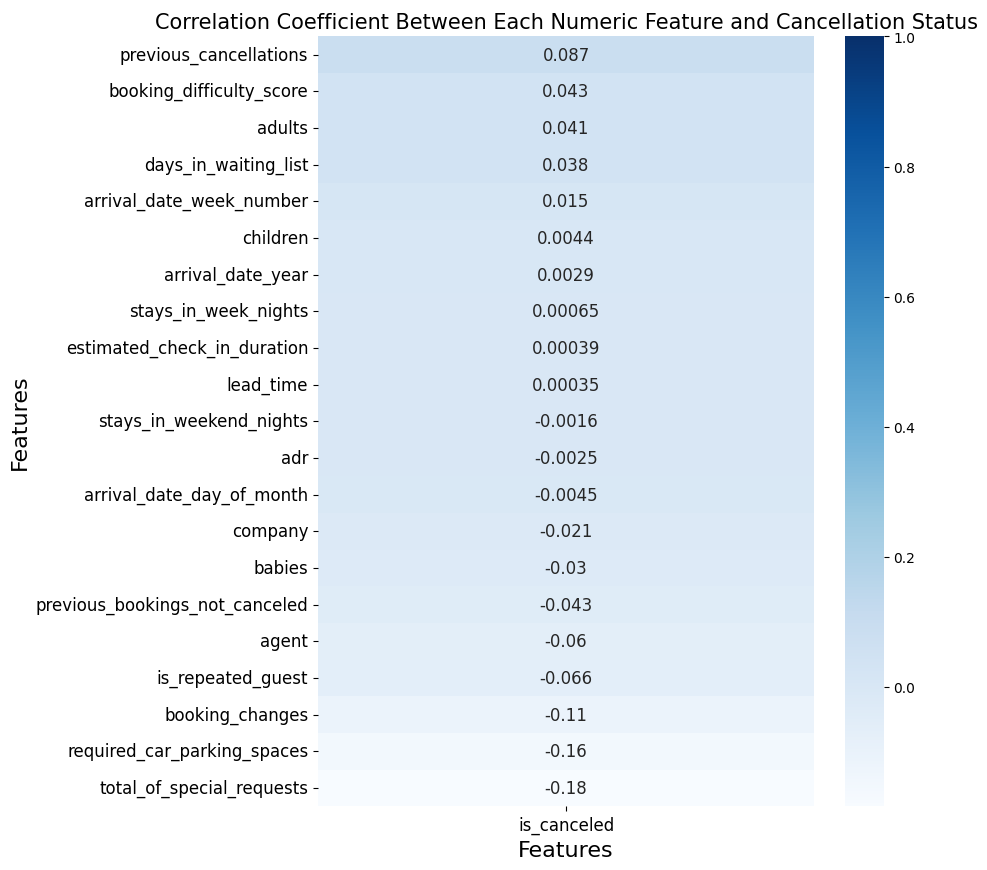

In [9]:
# Visualizing correlation coefficients between features and cancellation:
fig = plt.figure(figsize=(8,10))
ax = sns.heatmap(numerical_df_initial.corr()[['is_canceled']].sort_values('is_canceled', ascending=False), annot = True, annot_kws = {"size":12}, cmap='Blues')
ax.set_title('Correlation Coefficient Between Each Numeric Feature and Cancellation Status', fontsize=15)
ax.set_xlabel('Features', fontsize = 16)
ax.set_ylabel('Features', fontsize = 16)
ax.tick_params(axis = "both", labelsize = 12)
y_min, y_max = ax.get_ylim()
ax.set_ylim(top=y_max+1)

## Data Cleaning and preprocessing

In [10]:
def clean_data(df):
    df = df.copy()
    
    df = df.drop_duplicates(subset=['id', 'reservation_status_date'])
    
    df = df.dropna(subset=["meal", "adr", "booking_difficulty_score", "estimated_check_in_duration", "lead_time"])


    # Drop confidential columns if they exist
    confidential_cols = ['name', 'email', 'phone-number', 'credit_card']
    df = df.drop(columns=[col for col in confidential_cols if col in df.columns], errors='ignore')

    # Drop data leakage columns
    leakage_cols = ['meal',
        'reservation_status', 'reservation_status_Check-Out', 'reservation_status_Canceled',
        'reservation_status_No-Show', 'estimated_check_in_duration',
        'assigned_room_type', 'reservation_status_date'
    ]
    df = df.drop(columns=[col for col in leakage_cols if col in df.columns], errors='ignore')


    # Clean lead_time
    df['lead_time'] = df['lead_time'].apply(lambda x: x if 0 <= x <= 365 else np.nan)
    if 'lead_time' in df.columns:
        df['lead_time'] = df['lead_time'].fillna(df['lead_time'].median())
        df['lead_time'] = df['lead_time'].round().astype(int)


    # Rename arrival_date_year → arrival_date_week
    if 'arrival_date_year' in df.columns:
        df = df.rename(columns={'arrival_date_year': 'arrival_date_week'})
    if 'arrival_date_week' in df.columns:
        df['arrival_date_week'] = pd.to_numeric(df['arrival_date_week'], errors='coerce')
        df['arrival_date_week'] = df['arrival_date_week'].apply(lambda x: x if 1 <= x <= 53 else np.nan)

    # Fix month names
    df['arrival_date_month'] = df['arrival_date_month'].replace('Veganuary', 'January')

    # Rename arrival_date_week_number → arrival_date_year
    if 'arrival_date_week_number' in df.columns:
        df = df.rename(columns={'arrival_date_week_number': 'arrival_date_year'})

    # Day of month cleanup
    df['arrival_date_day_of_month'] = df['arrival_date_day_of_month'].apply(lambda x: x if 1 <= x <= 31 else np.nan)

    # Fix negative night stays
    df['stays_in_weekend_nights'] = df['stays_in_weekend_nights'].apply(lambda x: x if x >= 0 else np.nan)
    df['stays_in_week_nights'] = df['stays_in_week_nights'].apply(lambda x: x if x >= 0 else np.nan)
    
    df['stays_in_week_nights'] = df['stays_in_week_nights'].fillna(0)
    df['stays_in_weekend_nights'] = df['stays_in_weekend_nights'].fillna(0)


    # Market segment mode fill
    df['market_segment'] = df['market_segment'].astype(str).str.upper()
    most_common_segment = df.loc[~df['market_segment'].isin(['', 'UNAVAILABLE', 'MISSING', 'NAN']), 'market_segment'].mode()[0]
    df['market_segment'] = df['market_segment'].replace(['', 'UNAVAILABLE', 'MISSING', 'NAN'], np.nan)
    df['market_segment'] = df['market_segment'].fillna(most_common_segment)

    # Distribution channel mode fill
    df['distribution_channel'] = df['distribution_channel'].astype(str).str.upper()
    most_common_channel = df.loc[~df['distribution_channel'].isin(['', 'UNAVAILABLE', 'UNKNOWN', 'MISSING', 'NAN']), 'distribution_channel'].mode()[0]
    df['distribution_channel'] = df['distribution_channel'].replace(['', 'UNAVAILABLE', 'UNKNOWN', 'MISSING', 'NAN'], np.nan)
    df['distribution_channel'] = df['distribution_channel'].fillna(most_common_channel)

    df['country'] = df['country'].fillna(df['country'].mode()[0])
    df['agent'] = df['agent'].fillna(df['agent'].mode()[0])
    df['company'] = df['company'].fillna(df['company'].mode()[0])

    df['children'] = df['children'].fillna(0).astype(int)

    df = df[(df['adults'] > 0) & (df['adults'] <= 6)]

    
    df['days_in_waiting_list'] = df['days_in_waiting_list'].apply(lambda x: x if x >= 0 else np.nan)

    df['days_in_waiting_list'] = df['days_in_waiting_list'].fillna(0)


    # ADR: drop negatives, fill NaNs with mean
    df = df[df['adr'] >= 0]
    df['adr'] = df['adr'].fillna(df['adr'].mean())
    df['adr'] = df['adr'].round(2)

    # booking_difficulty_score: drop negatives, fill NaNs with mean
    df['booking_difficulty_score'] = df['booking_difficulty_score'].apply(lambda x: x if x >= 0 else np.nan)
    df['booking_difficulty_score'] = df['booking_difficulty_score'].fillna(df['booking_difficulty_score'].mean())

    return df


In [11]:
#Feature Engineering and engineer data
def feature_engineer(df):
    df = df.copy()
    
    df['total_bookings'] = df['previous_cancellations'] + df['previous_bookings_not_canceled']
    
    month_map = {'January':'01', 'February':'02', 'March':'03', 'April':'04', 'May':'05', 'June':'06', 'July':'07', 'August':'08', 'September':'09', 'October':'10', 'November':'11', 'December':'12'}
    
    df.arrival_date_month = df.arrival_date_month.map(month_map).astype(int)
    df['arrival_date'] = df['arrival_date_year'].astype(str)+'-'+df['arrival_date_month'].astype(str)+'-'+df['arrival_date_day_of_month'].astype(str)
    
    df['kids'] = (df['children'] + df['babies']).astype(int)
    
    df['total_bookings'] = df['previous_cancellations'] + df['previous_bookings_not_canceled']
    
    df['is_single'] = ((df['adults'] == 1) & (df['children'] == 0) & (df['babies'] == 0)).astype(int)
    
    df['group_size'] = df['adults'] + df['children'] + df['babies']
    
    df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
    df['long_stay'] = df['total_nights'].apply(lambda x: 1 if x >= 7 else 0)



    return df





In [12]:
# Clean 
df_train = clean_data(df_train)
df_test = clean_data(df_test)
df_train = feature_engineer(df_train)
df_test = feature_engineer(df_test)



In [13]:
print("Missing Values After Cleaning")
missing_values_cleaned = df_train.isnull().sum().sort_values(ascending=False)
print(missing_values_cleaned[missing_values_cleaned > 0]) # Should be empty for cleaned columns

Missing Values After Cleaning
Series([], dtype: int64)


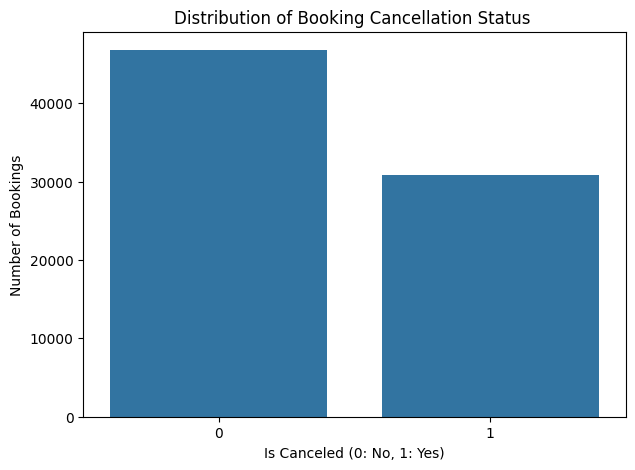

In [14]:
# Distribution of Target Variable 'is_canceled' (After Cleaning/Outlier Removal) ---
plt.figure(figsize=(7, 5))
sns.countplot(x='is_canceled', data=df_train)
plt.title('Distribution of Booking Cancellation Status ')
plt.xlabel('Is Canceled (0: No, 1: Yes)')
plt.ylabel('Number of Bookings')
plt.show()

In [15]:
# Save cleaned data to CSV files for reuse
df_train.to_csv('clean_train.csv', index=False)
df_test.to_csv('clean_test.csv', index=False) # Saving test data as well, useful for debugging


In [16]:
print(df_train["adults"].unique())


[2 1 3 4 6]


## Split the train data set into train/val/test

In [17]:
# Split the train data set into train/val/test
X = df_train.drop(["is_canceled", "id"], axis=1, errors='ignore')
y = df_train["is_canceled"]

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()


# 60% train, 20% val, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test_eval, y_val, y_test_eval = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)



In [18]:
#Create a preprocessor: OneHotEncoder for categorical features, StandardScaler for numeric features 
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)
X_test_eval_encoded = preprocessor.transform(X_test_eval)

#  Prepare the final test dataset for prediction 
# Drop 'id' column if present, then transform
df_test_features = df_test.drop(["id"], axis=1, errors='ignore')
df_test_processed = preprocessor.transform(df_test_features)

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_encoded, y_train)

print("Original class distribution:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_balanced).value_counts().to_dict())


Original class distribution: {0: 28160, 1: 18449}
After SMOTE: {0: 28160, 1: 28160}


## Logistic Regression Model & Random Forest 

In [22]:
# Logistic Regression
lr_model = LogisticRegression(C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=2000,
    random_state=42,
    class_weight='balanced')
lr_model.fit(X_train_balanced, y_train_balanced)
lr_pred = lr_model.predict(X_val_encoded)
lr_f1 = f1_score(y_val, lr_pred, average='weighted')

# Print scores
print(f"Logistic Regression: F1 Weighted = {lr_f1:.4f}")


Logistic Regression: F1 Weighted = 0.7147


In [23]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=500,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced')
rf_model.fit(X_train_balanced, y_train_balanced)
rf_pred = rf_model.predict(X_val_encoded)
rf_f1 = f1_score(y_val, rf_pred, average='weighted')

# Print scores
print(f"Random Forest: F1 Weighted = {rf_f1:.4f}")

Random Forest: F1 Weighted = 0.7514


In [24]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_balanced, y_train_balanced)
xgb_pred = xgb_model.predict(X_val_encoded)
xgb_f1 = f1_score(y_val, xgb_pred, average='weighted')

# Print scores
print(f"XGBoost: F1 Weighted = {xgb_f1:.4f}")

XGBoost: F1 Weighted = 0.7578


## Model Evaluation Plots and Matrices

Logistic Regression Evaluation


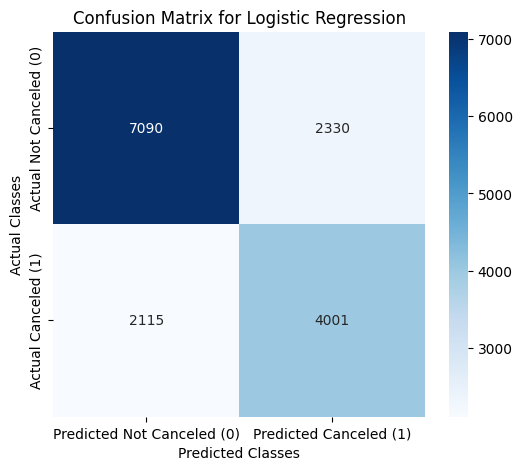

In [25]:
print("Logistic Regression Evaluation")
# Confusion Matrix for Logistic Regression
lr_cm = confusion_matrix(y_val, lr_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Not Canceled (0)', 'Predicted Canceled (1)'],
            yticklabels=['Actual Not Canceled (0)', 'Actual Canceled (1)'])
plt.xlabel('Predicted Classes')
plt.ylabel('Actual Classes')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()


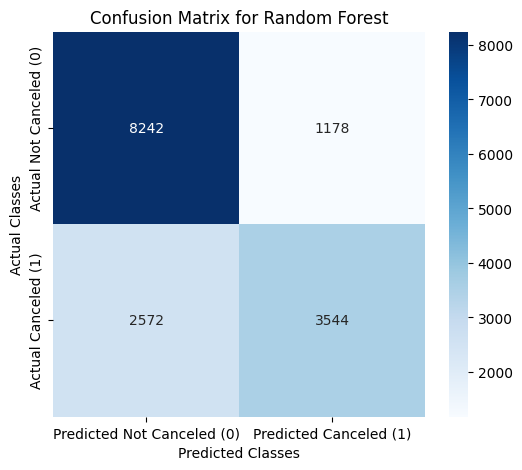

In [26]:
# Confusion Matrix for Random Forest
rf_cm = confusion_matrix(y_val, rf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Not Canceled (0)', 'Predicted Canceled (1)'],
            yticklabels=['Actual Not Canceled (0)', 'Actual Canceled (1)'])
plt.xlabel('Predicted Classes')
plt.ylabel('Actual Classes')
plt.title('Confusion Matrix for Random Forest')
plt.show()

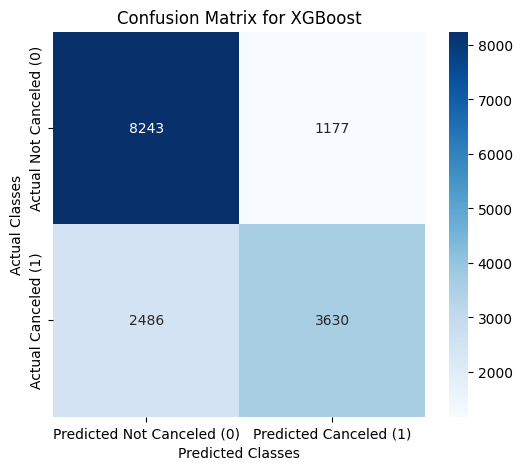

In [27]:
# Confusion Matrix for XGBoost
xgb_cm = confusion_matrix(y_val, xgb_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Not Canceled (0)', 'Predicted Canceled (1)'],
            yticklabels=['Actual Not Canceled (0)', 'Actual Canceled (1)'])
plt.xlabel('Predicted Classes')
plt.ylabel('Actual Classes')
plt.title('Confusion Matrix for XGBoost')
plt.show()



Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.76      0.87      0.81      9420
           1       0.75      0.58      0.65      6116

    accuracy                           0.76     15536
   macro avg       0.76      0.73      0.73     15536
weighted avg       0.76      0.76      0.75     15536



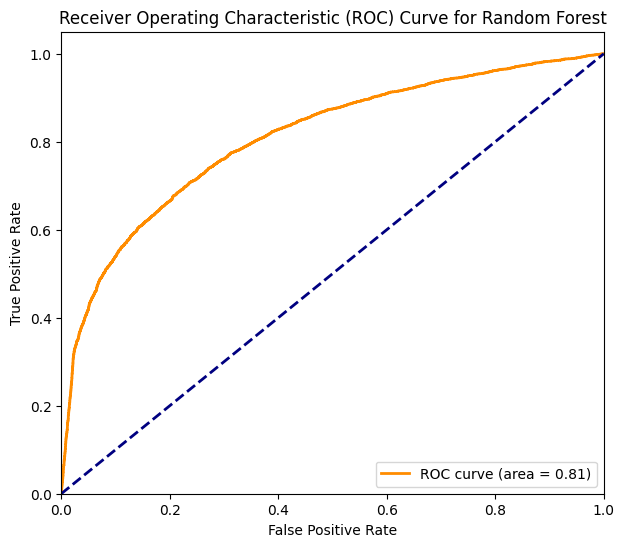

In [28]:
# Classification Report for Random Forest
print("\nClassification Report (Random Forest):\n", classification_report(y_val, rf_pred))

# ROC Curve for Random Forest
rf_proba = rf_model.predict_proba(X_val_encoded)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_val, rf_proba)
rf_roc_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(7, 6))
plt.plot(rf_fpr, rf_tpr, color='darkorange', lw=2, label=f'ROC curve (area = {rf_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest')
plt.legend(loc="lower right")
plt.show()

992 992


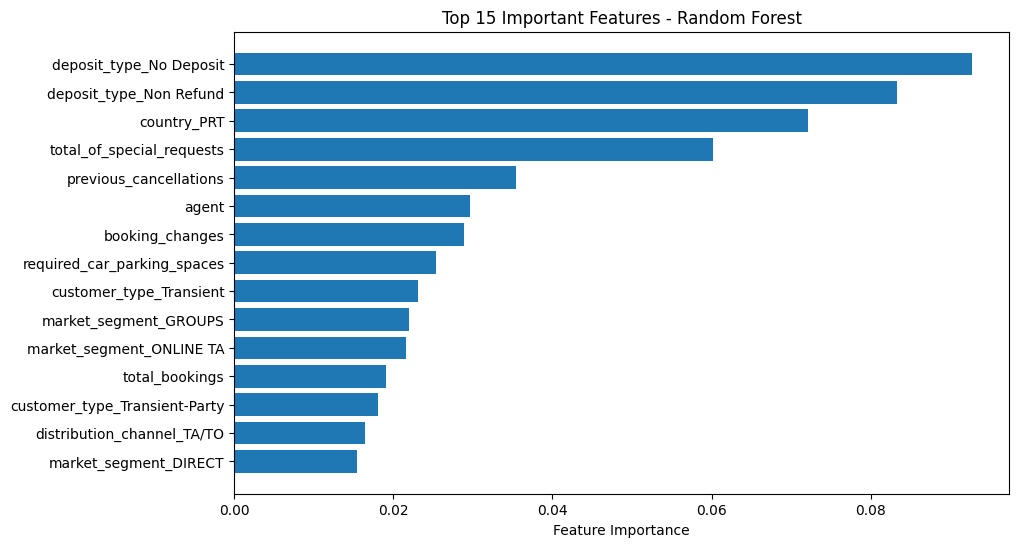

In [29]:
encoded_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)

all_features = np.concatenate([encoded_cat_features, numeric_cols])

print(len(all_features), len(rf_model.feature_importances_))

feature_importances = pd.DataFrame({
    'feature': all_features,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False).head(15)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['feature'][::-1], feature_importances['importance'][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Important Features - Random Forest")
plt.show()


In [30]:
# Final test set processing and prediction
test_ids = df_test["id"].values
df_test_features = df_test.drop(["id"], axis=1)
df_test_processed = preprocessor.transform(df_test_features)

In [31]:
# Final prediction with RF
final_predictions_rf = rf_model.predict(df_test_processed)

assert len(test_ids) == len(final_predictions_rf), "Lengths of IDs and predictions do not match!"

df_submission_rf = pd.DataFrame({
    "id": test_ids,
    "is_canceled": final_predictions_rf
})
df_submission_rf.to_csv("submission_rf.csv", index=False)

In [32]:
# Final prediction with Logistic Regression
final_predictions_lr = lr_model.predict(df_test_processed)

assert len(test_ids) == len(final_predictions_lr), "Lengths of IDs and predictions do not match!"

df_submission_lr = pd.DataFrame({
    "id": test_ids,
    "is_canceled": final_predictions_lr
})
df_submission_lr.to_csv("submission_lr.csv", index=False)

In [33]:
# Final prediction with XGBoost
final_predictions_xgb = xgb_model.predict(df_test_processed)

assert len(test_ids) == len(final_predictions_xgb), "Mismatch between IDs and predictions lengths"

df_submission_xgb = pd.DataFrame({
    "id": test_ids,
    "is_canceled": final_predictions_xgb
})
df_submission_xgb.to_csv("submission_xgb.csv", index=False)


In [34]:
# Save models separately
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(lr_model, "lr_model.pkl")
joblib.dump(xgb_model, "xgb_model.pkl")

# Save the entire preprocessor (OneHotEncoder + StandardScaler)
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

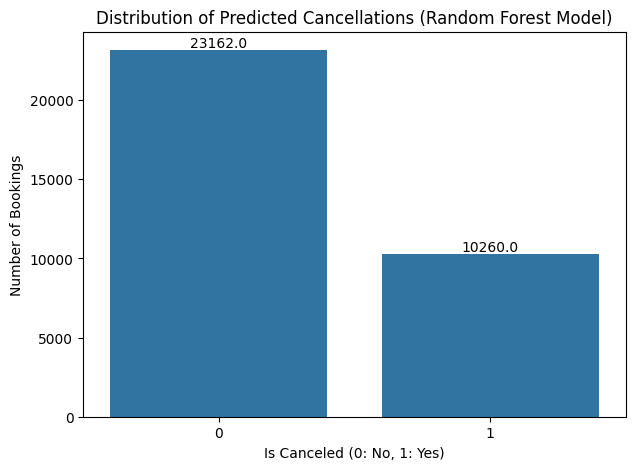

In [35]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='is_canceled', data=df_submission_rf)
plt.title('Distribution of Predicted Cancellations (Random Forest Model)')
plt.xlabel('Is Canceled (0: No, 1: Yes)')
plt.ylabel('Number of Bookings')

# Add count labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')

plt.show()